In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import janitor
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Importamos de Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 00. Setup

In [2]:
ruta_proyecto = "../02_datos/03_Entrenamiento/"
ruta_df_tablon = ruta_proyecto + "04_df_tablon.pkl"

df = pd.read_pickle(ruta_df_tablon)

# Avisamos al usuario
print("✅ Dataframe df_tablon exportado correctamente")

✅ Dataframe df_tablon exportado correctamente


### Separamos variables predictoras de la target

**NO se va a realizar** ya que estamos en un proyecto de **Aprendizaje No Supervisado**

# 01. Construir segmentación
---

### 1.1. Definimos el espacio de soluciones

In [3]:
# Establecemos entre 3 y 7, ya que no tenemos muchos datos como para elevar más el K.

min_k = 3
max_k = 7

soluciones = list(range(min_k, max_k))

### 1.2. Analizar el espacio de soluciones

In [4]:
codo = []
silueta = []
calins = []
davies = []

In [5]:
for solucion in soluciones:
    # Instanciamos
    cluster = KMeans(n_clusters=solucion, n_init=10)

    # Entrenar
    cluster.fit_transform(df)

    # Recoger las métricas
    codo.append(cluster.inertia_)
    silueta.append(silhouette_score(df, cluster.labels_))
    calins.append(calinski_harabasz_score(df, cluster.labels_))
    davies.append(davies_bouldin_score(df, cluster.labels_))

### 1.3. Analizamos mejor solución

In [6]:
metricas = pd.DataFrame({
    'Solucion': soluciones,
    'codo':codo,
    'silueta':silueta,
    'calins':calins,
    'davies':davies
}).set_index('Solucion')
metricas

,codo,silueta,calins,davies
Solucion,,,,
3,13077.750,0.188,1008.193,2.065
4,12323.475,0.199,811.723,1.834
5,11699.122,0.172,705.618,2.124
6,11253.867,0.153,624.934,2.140


### 1.4. Representamos gráficamente

array([[<Axes: xlabel='Solucion'>, <Axes: xlabel='Solucion'>],
       [<Axes: xlabel='Solucion'>, <Axes: xlabel='Solucion'>]],
      dtype=object)

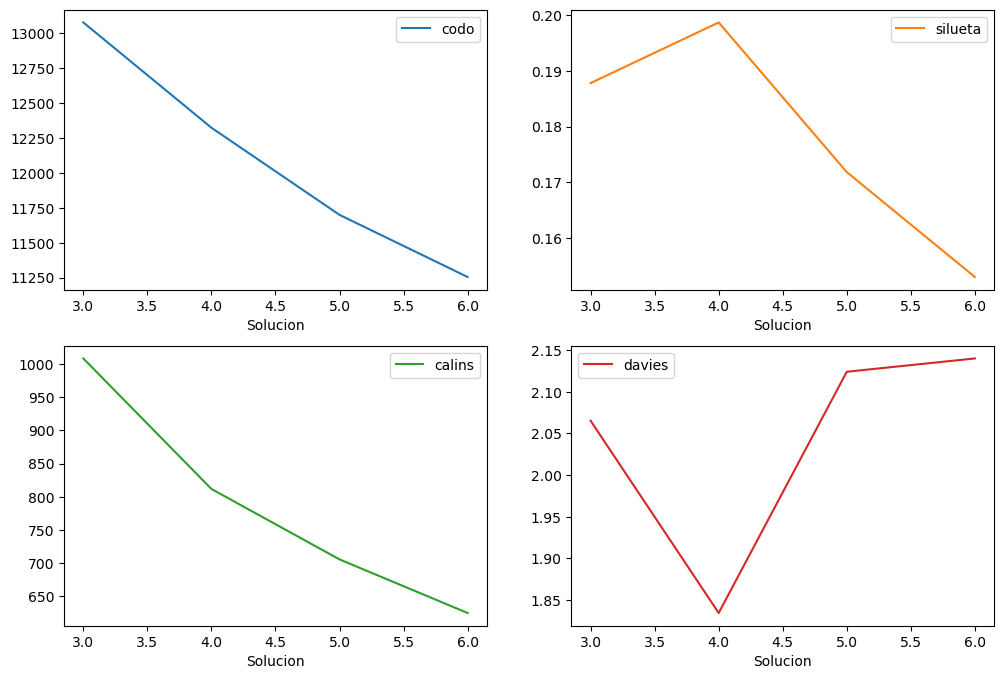

In [7]:
metricas.plot(subplots=True, figsize=(12,8), layout=(2,2), sharex=False)

# 02. Analizar el "k" que se usará
---

- **Técnica del codo**: decrece el error, por lo que buscamos, a más cluster tenderá a decrecer. Buscamos ese punto donde había saltos pronunciados. En nuestro caso vemos que la caída es poco pronunciada y baja poco a poco, no nos aporta mucha utilidad.
- **Técnica de la silueta**: lo que nos devuelve está entre -1 y 1 y cuánto más cerca esté del 1 significa mejor solución, mientras que si es 0 se solapan los cluster. Nos indica que entre 3 y 4 son buenas soluciones, **siendo la 4 la mejor** pero que 5 o 6 ya no lo son.
- **Técnica de Calins**: ratio de dispersión entre inter-cluster y dispersión intra-cluster, cuánto mayor sea significa mejor segmentación, por lo que, vemos que de nuevo que entre 3 y 4, siendo **3 es la mejor solución**.
- **Técnica de Davies**: se mueve entre 0 a infinito, siendo mejor segmentación a más cercano a 0. De nuevo, observamos que entre 0-4, **siendo 3 la que mejor solución proporciona-**

Con esta información, se considera que entre 3 y 4 nos dará mejor solución a nivel estadístico. Sin embargo, tenemos que definir un mejor perfil de negocio, podemos sacar nuevas variables de cada perfil y volver a realizar este K-Means a ver si nos interesa un K u otro. Se vuelve a repetir todo el proceso de nuevo.

# 03. Iteramos todo el proceso de nuevo con k entre 3 y 4
---

## 3.1. Estudiamos con K = 3

In [8]:
mejor_solucion = 3

# Instanciar
cluster = KMeans(n_clusters=mejor_solucion, n_init=10)

# Entrenar
cluster.fit_transform(df)

array([[2.1106977 , 2.20215987, 1.33734334],
       [1.51305639, 2.82785038, 2.43100682],
       [2.22353175, 2.31230198, 1.46818006],
       ...,
       [2.79785114, 1.52322509, 2.31872493],
       [1.39536075, 2.64008122, 2.23564561],
       [1.51951822, 2.70647269, 2.3140428 ]], shape=(4837, 3))

In [9]:
# Calcular segmento
df['segmento'] = cluster.predict(df)

In [10]:
# Perfilar los segmentos

df.groupby('segmento').mean().T \
    .style.highlight_max(color='lightgreen', axis= 1) \
    .highlight_min(color='red', axis= 1)

segmento,0,1,2
origen_API,0.948086,0.031025,0.000000
origen_Landing Page Submission,0.000000,0.963435,0.880617
origen_Lead Add Form,0.035691,0.005540,0.113347
origen_OTROS,0.016223,0.000000,0.006036
fuente_Chat,0.166775,0.018837,0.000000
fuente_Direct Traffic,0.045425,0.685873,0.169014
fuente_Google,0.503569,0.085873,0.647887
fuente_OTROS,0.068787,0.008310,0.015426
fuente_Organic Search,0.186243,0.195568,0.059021
fuente_Reference,0.029202,0.005540,0.108652


### Análisis de la tabla
En la tabla anterior podemos observa cada uno de los segmentos que nos ha generado con el valor de la media de cada uno de ellos. En aquellos el valor máximo es verde y el valor mínimo es rojo. Así podemos ver a golpe de vista que los que vienen más de la API son los del segmento 2 y los que vienen menos los del segmento 0.

- `origen`: podemos ver que esta variable está muy bien segmentada entre los que vienen de una fuente u otra. 
- `fuente`: vemos que el segmento 2 viene de chat, el segmento 1 de tráfico directo o búsqueda orgánica y el segmento 0 de google o referidos.

Con esta información ya podemos extraer ciertas inferencias, por ejemplo, el segmento 2 viene del chat que seguramente será la API, el segmento 1 viene de tráfico directo u orgánico y rellena el formulario de la página. Y el segmento 0 viene principalmente a través de Google y rellena el formulario que está en alguna página. El segmento 0 y 1 no están tan diferenciados.

- `ult_actividad`: el segmento 2 la ultima actividad ha sido conversación de chat y a partir de ahí ha convertido en lead y ha hecho click en un email; el segmento 1 ha sido abrir mail y abrir página de website; y el segmento 0 ultima actividad de OTROS. No da mucha información muy clara entre segmentos. 
- `ambito`: el segmento 2 no ha rellenado en qué ámbito trabaja y no quiere rellenarlo. 
- `ocupacion`: observamos que la mayoría del segmento 2 son desempleados, el segmento 1 trabajadores.
- `descarga`: el segmento 0 no se descarga el LM y el segmento 1 el 100%. 
- `compra`: vemos que el segmento que más convierte sería el segmento 0. Sin embargo, vemos que las diferencias en conversión no son demasiado grandes, asi que en este caso desde negocio no nos interesa demasiado.

## 3.2. Estudiamos con K = 5

In [11]:
mejor_solucion = 5

# Instanciar
cluster_2 = KMeans(n_clusters=mejor_solucion, n_init=10)

# Entrenar
cluster_2.fit_transform(df)

array([[2.71602267, 2.90775597, 1.27416994, 2.58502703, 2.33605125],
       [3.11460124, 1.51305639, 3.18723478, 3.37712233, 3.02359354],
       [2.32903042, 2.99066772, 1.44973459, 2.49031188, 2.74107505],
       ...,
       [1.77115905, 2.97119017, 2.51986682, 3.14498469, 1.5396418 ],
       [3.00393867, 1.39536075, 3.05155753, 3.15584205, 2.81092608],
       [2.71746987, 1.51951822, 3.10821573, 3.22692064, 3.08452484]],
      shape=(4837, 5))

In [12]:
# Calcular segmento
df['segmento'] = cluster_2.predict(df)

In [13]:
# Perfilar los segmentos

df.groupby('segmento').mean().T \
    .style.highlight_max(color='lightgreen', axis= 1) \
    .highlight_min(color='red', axis= 1)

segmento,0,1,2,3,4
origen_API,0.031564,0.948086,0.000000,0.000000,0.030937
origen_Landing Page Submission,0.967001,0.000000,0.993944,0.000000,0.969063
origen_Lead Add Form,0.001435,0.035691,0.000000,0.994413,0.000000
origen_OTROS,0.000000,0.016223,0.006056,0.005587,0.000000
fuente_Chat,0.022956,0.166775,0.000000,0.000000,0.016379
fuente_Direct Traffic,0.657102,0.045425,0.190765,0.000000,0.709736
fuente_Google,0.103300,0.503569,0.730507,0.005587,0.075523
fuente_OTROS,0.008608,0.068787,0.012112,0.039106,0.008189
fuente_Organic Search,0.206600,0.186243,0.066616,0.000000,0.190173
fuente_Reference,0.001435,0.029202,0.000000,0.955307,0.000000


### Análisis de la tabla

Ahora si observamos los 4 grupos distintos observamos una diferencia grande de conversión: **0.9 en el segmento 3**. 

- `origen`: podemos ver que esta variable está muy bien segmentada entre los que vienen de una fuente u otra. 
- `fuente`: vemos que el segmento 2 viene de chat, el segmento 1 de tráfico directo o búsqueda orgánica y el segmento 0 de google o referidos.

Con esta información ya podemos extraer ciertas inferencias, por ejemplo, el segmento 2 viene del chat que seguramente será la API, el segmento 1 viene de tráfico directo u orgánico y rellena el formulario de la página. Y el segmento 0 viene principalmente a través de Google y rellena el formulario que está en alguna página. El segmento 0 y 1 no están tan diferenciados.

- `ult_actividad`: el segmento 2 la ultima actividad ha sido conversación de chat y a partir de ahí ha convertido en lead y ha hecho click en un email; el segmento 1 ha sido abrir mail y abrir página de website; y el segmento 0 ultima actividad de OTROS. No da mucha información muy clara entre segmentos. 
- `ambito`: el segmento 2 no ha rellenado en qué ámbito trabaja y no quiere rellenarlo. 
- `ocupacion`: observamos que la mayoría del segmento 2 son desempleados, el segmento 1 trabajadores.
- `descarga`: el segmento 0 no se descarga el LM y el segmento 1 el 100%. 
- `compra`: vemos que el segmento que más convierte sería el segmento 0. Sin embargo, vemos que las diferencias en conversión no son demasiado grandes, asi que en este caso desde negocio no nos interesa demasiado.

# 4. Mejor solución tras investigar

In [20]:
df_2 = df.drop(columns=['fuente_Chat',
                 'fuente_Direct Traffic',
                 'fuente_Google',
                 'fuente_OTROS',
                 'fuente_Organic Search',
                 'fuente_Reference',
                 'score_actividad_mms',
                 'score_perfil_mms',
                 'ambito_Banking, Investment And Insurance',
                 'ambito_Business Administration',
                 'ambito_Finance Management',
                 'ambito_Human Resource Management',
                 'ambito_Healthcare Management',
                 'ambito_IT Projects Management',
                 'ambito_International Business',
                 'ambito_Marketing Management',
                 'ambito_Media and Advertising',
                 'ambito_OTROS',
                 'ambito_Operations Management',
                 'ambito_Select',
                 'ambito_Supply Chain Management',
                 'ambito_Travel and Tourism',
                 'descarga_lm_No',
                 'descarga_lm_Yes',
                 'visitas_total_mms',
                 'paginas_vistas_visita_mms'
                 ])

### 4.1. Definimos el espacio de soluciones

In [21]:
# Establecemos entre 3 y 7, ya que no tenemos muchos datos como para elevar más el K.

min_k = 3
max_k = 7

soluciones = list(range(min_k, max_k))

### 4.2. Analizar el espacio de soluciones

In [22]:
codo = []
silueta = []
calins = []
davies = []

In [23]:
for solucion in soluciones:
    # Instanciamos
    cluster_3 = KMeans(n_clusters=solucion, n_init=10)

    # Entrenar
    cluster_3.fit_transform(df_2)

    # Recoger las métricas
    codo.append(cluster_3.inertia_)
    silueta.append(silhouette_score(df, cluster_3.labels_))
    calins.append(calinski_harabasz_score(df, cluster_3.labels_))
    davies.append(davies_bouldin_score(df, cluster_3.labels_))

### 4.3. Analizamos mejor solución

In [24]:
metricas_2 = pd.DataFrame({
    'Solucion': soluciones,
    'codo':codo,
    'silueta':silueta,
    'calins':calins,
    'davies':davies
}).set_index('Solucion')
metricas_2

,codo,silueta,calins,davies
Solucion,,,,
3,7641.115,0.236,1791.731,1.720
4,6016.368,0.292,1874.033,1.466
5,5452.245,0.301,1581.052,1.407
6,5012.521,0.258,1351.157,1.677


### 4.4. Representamos gráficamente

array([[<Axes: xlabel='Solucion'>, <Axes: xlabel='Solucion'>],
       [<Axes: xlabel='Solucion'>, <Axes: xlabel='Solucion'>]],
      dtype=object)

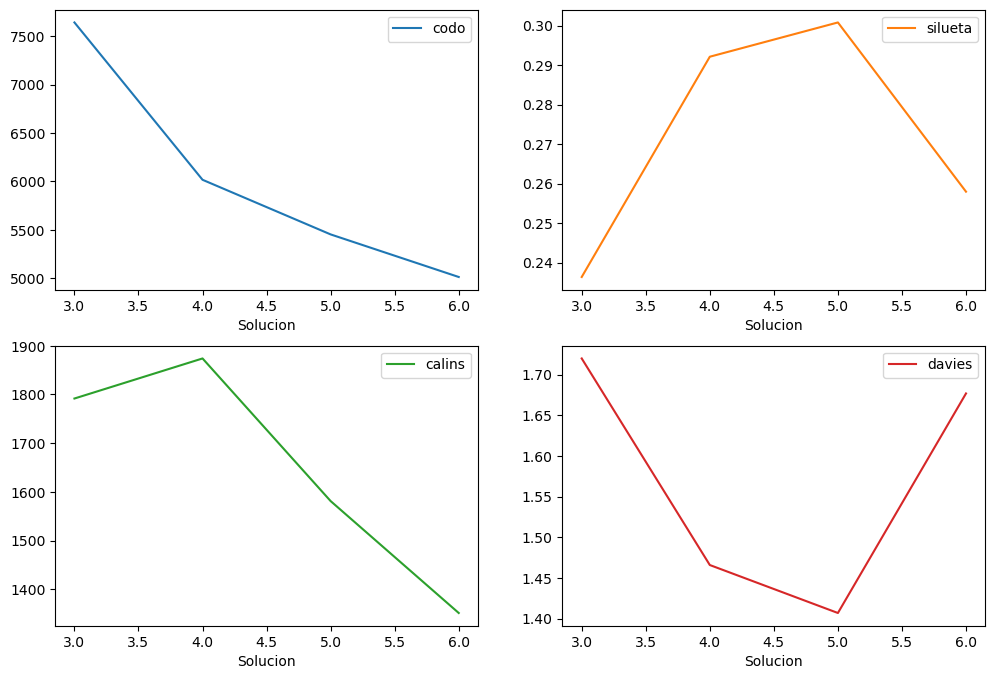

In [25]:
metricas_2.plot(subplots=True, figsize=(12,8), layout=(2,2), sharex=False)

# 5. Implementamos

In [46]:
mejor_solucion = 5

# Instanciar
cluster_3 = KMeans(n_clusters=mejor_solucion, n_init=10)

# Entrenar
cluster_3.fit_transform(df_2)

array([[1.81413622, 2.13500409, 3.22348123, 0.42595859, 4.40175753],
       [2.88869203, 1.13423586, 2.67766265, 2.27408852, 3.61505395],
       [0.45577555, 2.97546801, 4.24585088, 1.87075212, 5.23975173],
       ...,
       [4.27062659, 2.40364586, 0.87178946, 3.33336486, 2.23134172],
       [3.62084475, 1.14901256, 2.238779  , 2.5456832 , 2.52906762],
       [2.51184637, 1.22957577, 2.86098659, 2.37162186, 3.40368742]],
      shape=(4837, 5))

In [47]:
# Calcular segmento
df_2['segmento'] = cluster_3.predict(df_2)

In [48]:
# Perfilar los segmentos

df_2.groupby('segmento').mean().T \
    .style.highlight_max(color='lightgreen', axis= 1) \
    .highlight_min(color='red', axis= 1)

segmento,0,1,2,3,4
origen_API,0.000000,0.977194,0.000000,0.000000,0.238426
origen_Landing Page Submission,0.999035,0.000000,0.998350,0.994681,0.238426
origen_Lead Add Form,0.000965,0.005529,0.000000,0.000000,0.520833
origen_OTROS,0.000000,0.017277,0.001650,0.005319,0.002315
ult_actividad_Chat Conversation,0.007722,0.140290,0.080858,0.000000,0.013889
ult_actividad_Converted to Lead,0.011583,0.074637,0.264026,0.000000,0.020833
ult_actividad_Email Link Clicked,0.011583,0.034554,0.110561,0.000000,0.046296
ult_actividad_Email Opened,0.000000,0.384934,0.000000,1.000000,0.354167
ult_actividad_OTROS,0.013514,0.039392,0.158416,0.000000,0.173611
ult_actividad_Page Visited on Website,0.000965,0.070491,0.386139,0.000000,0.062500


In [49]:
df_2.segmento.value_counts(normalize=True)

segmento
1   0.299
3   0.272
0   0.214
2   0.125
4   0.089
Name: proportion, dtype: float64

Tenemos segmentos que convierten muy bien y otros que no convierten tan bien que son:
- **Sectores que convierten bien**: empleados en activo, aquellos que dedican tiempo en el site. También observamos que existen una serie de leads que vienen por el chat (Chat Converation) pero que no convierte mucho (14% vienen de ahí y convierte poco, 33%), por lo que, quizás podríamos eliminarlo. 
- **Sectores que no convierten mucho**: vienen del chat, desempleados y abren email pero no convierten. 


Nos interesan los segmentos 1 y 3 que son los que más convierten y vemos que son el 8,9% y el 21,4%, por lo que, entorno a un 20-30% son leads de muy buena calidad. Los que menos convierten podríamos prescindir de estos leads (entorno a 4-50%) y analizar de forma profunda cómo están llegando para ver si **podemos obtener algún insight de valor**.

En este caso vamos a realizar las siguientes acciones:

- Priorizar aquellos leads que convierten más: empleados en activo con tiempo en el site.
- Reducir los recursos a Chat ya que convierten menos.
- Reducir envíos con emails solo para profesionales en activo con tiempo.
- Mantener el SMS de recordatorio tras la página de formulario que funciona muy bien.